**1. Importing Libraries**

In [54]:
# 1. Importing Libraries

# Data manipulation
import pandas as pd
import numpy as np

# Data preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Model: Isolation Forest
from sklearn.ensemble import IsolationForest

# Evaluation metrics (if labeled data is available)
from sklearn.metrics import classification_report

# Keras libraries for neural network
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint

# Visualization libraries
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

**2. Load and Inspect the Dataset**

In [55]:
# Load dataset
file_path = '/kaggle/input/file-access-paterns-detection/generated_file_access_pattern.csv'
dataset = pd.read_csv(file_path)

# Display the first few rows of the dataset
print(dataset.head())

                         id         timestamp        date   time  Hours    pc  \
0  {E7S2-F4AT85UB-1127IHSB}  01/02/2010 20:56  01/02/2010  20:56     13  7171   
1  {K0C9-U3NS32PB-6241HBAX}  01/05/2010 18:05  01/05/2010  18:05     11  3471   
2  {W8H3-G4CX82PI-7135QTTI}  01/04/2010 15:50  01/04/2010  15:50     21   326   
3  {V2O5-I0OZ19KG-4506EPFV}  01/03/2010 23:50  01/03/2010  23:50      9  6509   
4  {M7C3-Y5CX32UN-1159QUKG}  01/01/2010 18:43  01/01/2010  18:43     16  2771   

   user  Rapid_file_access                 filename extension  ...  \
0  1928                  0  R:\152zlk8\T8CJYVE6.doc       doc  ...   
1   273                  0  R:\51n6647\8P4FHIG9.txt       txt  ...   
2  2437                  0  R:\BPD2437\TRCUTR9U.doc       exe  ...   
3  1254                  0  C:\59CMV31\QMH6USRJ.doc       doc  ...   
4  3330                  0  R:\93Vl773\K5R7Q4CJ.doc       doc  ...   

  from_removable_media           file_signature  \
0                 True  D0-CF-11-E0-A1-B1

**3. Data Preprocessing**

In [56]:
# Ensure 'timestamp' is in datetime format
dataset['timestamp'] = pd.to_datetime(dataset['timestamp'])

# Sort by 'user' and 'timestamp' to ensure the rolling window works correctly
dataset = dataset.sort_values(by=['user', 'timestamp'])

# Calculate the time difference between consecutive accesses
dataset['time_diff'] = dataset.groupby('user')['timestamp'].diff().fillna(pd.Timedelta(0))

# Handle any time_diff that might be too large or NaN
dataset['time_diff'] = dataset['time_diff'].fillna(pd.Timedelta(0))

# Calculate the number of accesses within the last 30 minutes
dataset['access_frequency'] = dataset.groupby('user')['time_diff'].apply(lambda x: (x <= pd.Timedelta('30min')).sum())

# Handle NaN values in 'access_frequency', filling them with 0 (or you could use other strategies)
dataset['access_frequency'] = dataset['access_frequency'].fillna(0)

# Extract relevant features (hour, weekday, etc.)
dataset['hour'] = dataset['timestamp'].dt.hour
dataset['weekday'] = dataset['timestamp'].dt.weekday

# Select the features you need
features = ['hour', 'weekday', 'access_frequency', 'user', 'file_signature']  # Adjust based on available features

# Display the result
print(dataset[['timestamp', 'user', 'access_frequency', 'hour', 'weekday']].head())

# Handle missing values using forward fill
dataset.ffill(inplace=True)

# Define only numeric features for scaling (exclude non-numeric columns like 'file_signature')
numeric_features = ['hour', 'access_frequency', 'weekday']  # Adjust as necessary

# Apply StandardScaler only to numeric features
scaler = StandardScaler()

# Fit and transform the numeric features
dataset_scaled = scaler.fit_transform(dataset[numeric_features])

# Convert the result back into a DataFrame, and replace the original numeric columns
dataset[numeric_features] = dataset_scaled

# Display the result
print(dataset[['timestamp', 'user', 'access_frequency', 'hour', 'weekday']].head())


                timestamp  user  access_frequency  hour  weekday
76279 2010-01-01 00:58:00     1               0.0     0        4
44282 2010-01-01 01:04:00     1               0.0     1        4
17707 2010-01-01 01:51:00     1               0.0     1        4
32958 2010-01-01 02:14:00     1               0.0     2        4
2516  2010-01-01 02:17:00     1               0.0     2        4
                timestamp  user  access_frequency      hour   weekday
76279 2010-01-01 00:58:00     1         -0.034304 -1.658893  0.345903
44282 2010-01-01 01:04:00     1         -0.034304 -1.514135  0.345903
17707 2010-01-01 01:51:00     1         -0.034304 -1.514135  0.345903
32958 2010-01-01 02:14:00     1         -0.034304 -1.369378  0.345903
2516  2010-01-01 02:17:00     1         -0.034304 -1.369378  0.345903


**4. Train-Test Split**

In [57]:
# Train-test split (80% train, 20% test)
X_train, X_test = train_test_split(dataset_scaled, test_size=0.2, random_state=42)


**5. Model Initialization**

In [58]:
# Initialize Isolation Forest model
iso_forest = IsolationForest(contamination=0.05, random_state=42)

**6. Model Training**

In [59]:

# Fit the model to the training data
iso_forest.fit(X_train)

IsolationForest(contamination=0.05, random_state=42)

**7. Keras Model for Anomaly Detection (Neural Network Approach)**

In [60]:
# Build the neural network model
model = Sequential()

# Input layer with increased neurons
model.add(Dense(128, input_dim=X_train.shape[1], kernel_regularizer='l2'))  # L2 regularization
model.add(LeakyReLU(alpha=0.1))  # LeakyReLU activation instead of ReLU
model.add(BatchNormalization())  # Batch normalization

# Hidden layers with more neurons and dropout for regularization
model.add(Dense(128, kernel_regularizer='l2'))  
model.add(LeakyReLU(alpha=0.1))
model.add(Dropout(0.5))  # Dropout for regularization

model.add(Dense(64, kernel_regularizer='l2'))  
model.add(LeakyReLU(alpha=0.1))
model.add(Dropout(0.5))  # Dropout for regularization

# Output layer (same as input dimension, but you might want to adjust based on task)
model.add(Dense(X_train.shape[1], activation='sigmoid'))  # Output layer (same as input dimension)

# Compile the model with a learning rate scheduler or lower learning rate
optimizer = Adam(learning_rate=0.0005)  # Reduced learning rate
model.compile(optimizer=optimizer, loss='mean_squared_error')

# Implement EarlyStopping to monitor validation loss and prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# ModelCheckpoint to save the best model based on validation loss
model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, mode='min')

# Train the model with callbacks for early stopping and model saving
history = model.fit(X_train, X_train, epochs=100, batch_size=32, validation_split=0.1, verbose=1,
                    callbacks=[early_stopping, model_checkpoint])

# Load the best model
model_loaded = load_model('best_model.h5')

# Make predictions with the trained model
new_prediction = model_loaded.predict(X_train)  # Example prediction using the loaded model
print(new_prediction[:10])  # Display the first 10 predictions

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


2250/2250 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1.2356 - val_loss: 0.6872
Epoch 2/100
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.6609 - val_loss: 0.6787
Epoch 3/100
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.6549 - val_loss: 0.6763
Epoch 4/100
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.6843 - val_loss: 0.6737
Epoch 5/100
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.7310 - val_loss: 0.6770
Epoch 6/100
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.6749 - val_loss: 0.6705
Epoch 7/100
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.7092 - val_loss: 0.6711
Epoch 8/100
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.5388 - val_loss: 0.6729
Epoch 9/100
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.6611 - val_loss: 0.6711
Epoch 10/100
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.6145 - val_loss: 0.6708
Epoch 11/100
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.6111 - val_loss: 0.6672
Epoch 12/100
2250/2250 ━━━━━━━━

**8. Evaluate the Model**

In [61]:
# Predict anomalies in the test set using Isolation Forest
y_pred = iso_forest.predict(X_test)

# Convert predictions: 1 = normal, -1 = anomaly
y_pred = np.where(y_pred == 1, 'normal', 'anomaly')

**9. Model Evaluation - Silhouette Score**

Silhouette Score:  0.3423463332160249


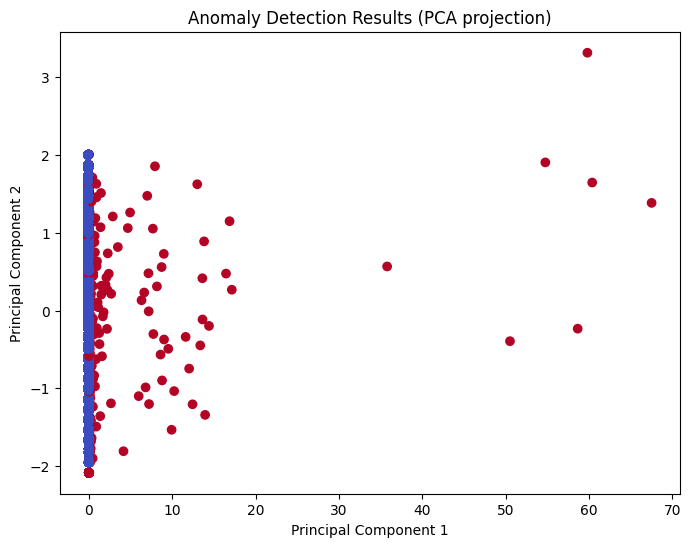

In [62]:
# Compute Silhouette Score to evaluate clustering
sil_score = silhouette_score(X_test, y_pred)
print("Silhouette Score: ", sil_score)

# PCA for visualization of anomalies and normal data points
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_test)

# Convert 'normal' to 0 and 'anomalous' to 1 for plotting
y_pred_numeric = np.where(y_pred == 'normal', 0, 1)

# Plot the data points
plt.figure(figsize=(8,6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_pred_numeric, cmap='coolwarm', marker='o')
plt.title("Anomaly Detection Results (PCA projection)")
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

**10. Real-time Anomaly Detection**

In [63]:
# Sample new data for real-time prediction
new_data = np.array([[12, 3, 5, 2394, 'D0-CF-11-E0-A1-B1-1A-E1']])  # 4 features: 3 numeric + 1 non-numeric

# Step 1: Exclude the non-numeric 'file_signature' column (last column)
new_data_numeric = new_data[:, :3]  # Keep only the first 3 columns (numeric)
print("New data shape after exclusion:", new_data_numeric.shape)

# Step 2: Preprocess and scale the new data
new_data_scaled = scaler.transform(new_data_numeric)  # Transform based on the scaler fitted on training data

# Step 3: Predict if this new data is an anomaly using Isolation Forest
new_prediction = iso_forest.predict(new_data_scaled)

# Step 4: Convert prediction result
if new_prediction == 1:
    print("Normal Access")
else:
    print("Anomalous Access")

New data shape after exclusion: (1, 3)
Anomalous Access


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
